## Import libraries

In [1]:
import mat73
import io, os, random
import numpy as np
import time
import math
import pickle
from matplotlib import pyplot as plt
from IPython.display import clear_output
from scipy.signal import spectrogram
import gc

Reproducibility with seed for numpy

In [2]:
np.random.seed(2026)

Open an NPY file with numpy

In [3]:
file_name = "./LoRa_SF07_v1_filtered_chunks.npy"
complex_blocks = np.load(file_name)
print(complex_blocks.shape)

(4096, 1024)


In [4]:
single_block = complex_blocks[0]

In [5]:
def get_fft(signal, fs, nfft=1024):
    fft = np.fft.fft(signal, n=nfft)
    fft = np.fft.fftshift(fft)  # Shift the zero frequency component to the center
    fft_freqs = np.fft.fftfreq(nfft, d=1/fs)
    fft_freqs = np.fft.fftshift(fft_freqs)  # Shift the frequency axis to the center
    return fft, fft_freqs

Function to plot time and frequency domain for a single chunk

In [6]:
def plot_signal_features(signal, fs=2e6, nfft=1024):
    plt.figure(figsize=(12, 3))
    plt.plot(np.real(signal), label="I")  # Plot the real part of the first 2048 samples
    plt.plot(np.imag(signal), label="Q")  # Plot the imaginary part of the first 2048 samples
    plt.title("Signal samples")
    plt.xlabel("Sample")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.show()
    fft, freqs = get_fft(signal, fs=fs, nfft=nfft)
    plt.figure(figsize=(12, 3))
    plt.plot(freqs, 20 * np.log10(np.abs(fft)))
    plt.title("Spectrum")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude")
    plt.show()

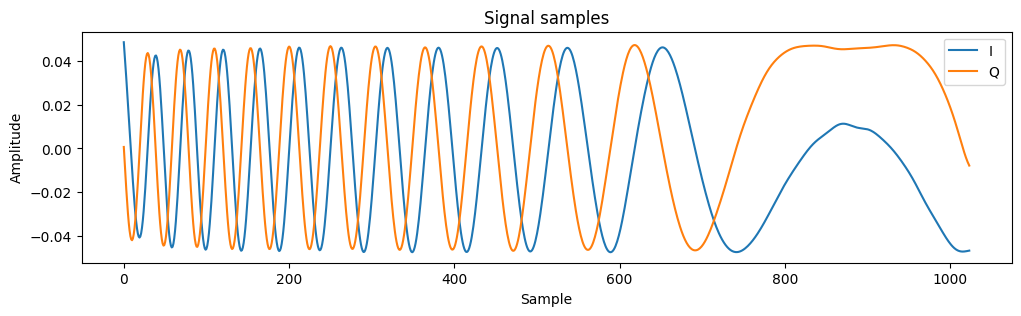

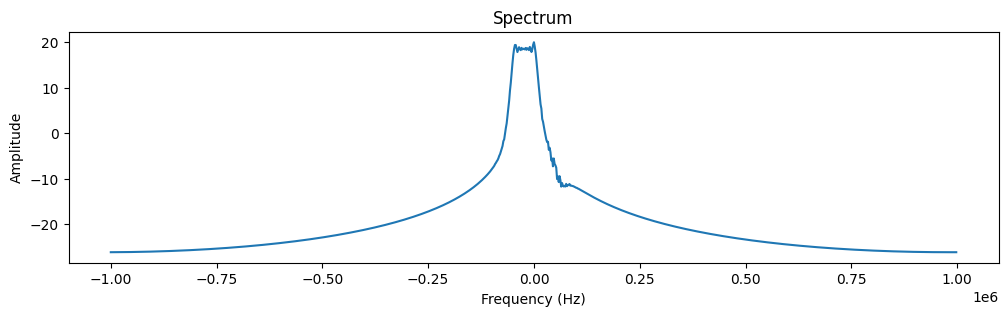

In [7]:
plot_signal_features(single_block, fs=2e6, nfft=1024)

The AWGN function will apply additive gaussian noise to the signal to the specified SNR (signal to noise ratio). To do this:
* Measure the power of the signal (average of squared magnitudes across all the samples). This is generally similar to the signal variance (if the signal has zero-mean).
* Given a desired SNR level in dB, it is transformed to a linear scale.
* The noise power is calculated as the ratio between signal power over the linear SNR value.
* The noise sequence is generated as follows: a complex random sequence with the same length as the chunk is multiplied by the noise amplitude, which is defined as the square root of the noise power. The factor 2 divides the noise power for the two components (real and imaginary). For instance, if the noise power is 1, it needs to provide 0.5 for the real component and 0.5 for the imaginary part.
* Finally, the noise sequence is added to the original signal.

In [8]:
def awgn(signal, snr_db):
    signal_power = np.mean(np.abs(signal)**2)
    snr_linear = 10 ** (snr_db / 10)
    noise_power = signal_power / snr_linear
    noise = np.sqrt(noise_power / 2) * (np.random.randn(*signal.shape) + 1j * np.random.randn(*signal.shape))
    return signal + noise

Example of applying AWGN targeting a SNR of 24 dB

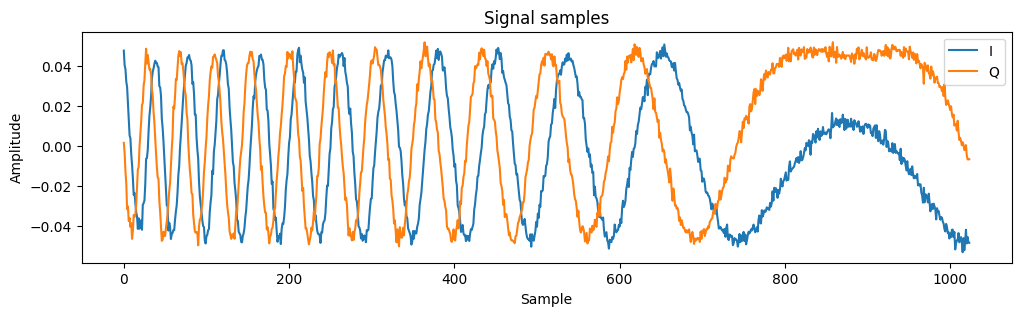

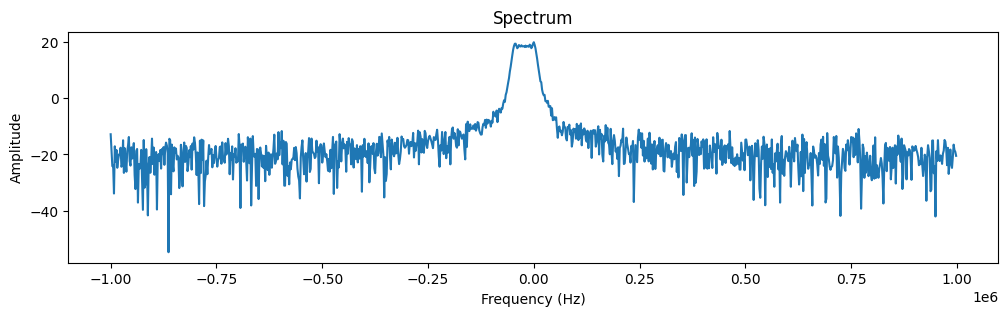

In [9]:
noisy_block = awgn(single_block, snr_db=24)
plot_signal_features(noisy_block, fs=2e6, nfft=1024)

Example of applying AWGN for all the SNR values mentioned in the RadioML 2018A dataset. The 4096 blocks are applied AWGN for an SNR of -20dB, then the same process is applied to reach -18dB and so on until 30 dB. The total length of the output is: 26*4096=106496

In [10]:
snr_range = np.arange(-20,31,2)
noisy_blocks = []
for snr in snr_range:
    for block in complex_blocks:
        noisy_block = awgn(block, snr_db=snr)
        noisy_blocks.append(noisy_block)
print(np.array(noisy_blocks).shape)

(106496, 1024)


This produces a list where the first 4096 chunks or 'frames' have -20dB, the next 4096 ones have -18dB, ..., and the final 4096 frames have +30dB

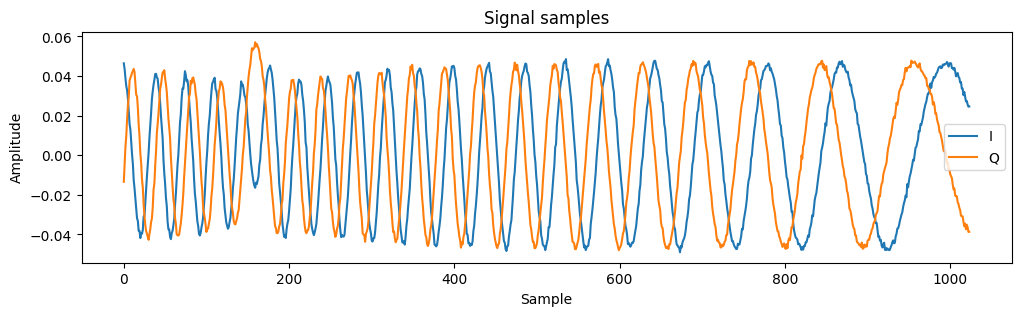

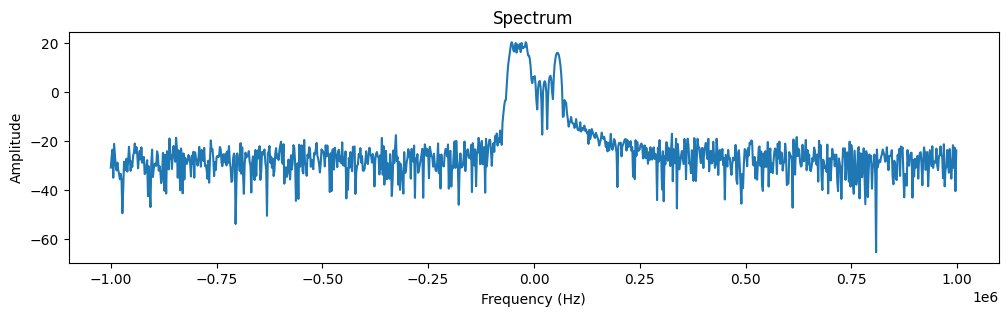

In [11]:
plot_signal_features(noisy_blocks[106400], fs=2e6, nfft=1024)

## Adding noise to all the signals
Applied for all the NPY files
* Continuing the RadioML dataset, the next labels will be 24, 25, ..., 29
* X, Y, Z will store the IQ samples, one-hot class labels and the SNR values, respectively.
* Since after adding the noise each chunk is still complex, stacking of separated real and imaginary component is applied. This leads to a shape (1024, 2) per chunk.
* Data types are defined for X, Y, and Z

In [12]:
# Defines the path to the .mat file.
path = './'
file_names = ["LoRa_SF07_v1_filtered_chunks.npy", "LoRa_SF08_v1_filtered_chunks.npy", "LoRa_SF09_v1_filtered_chunks.npy", "LoRa_SF10_v1_filtered_chunks.npy", "LoRa_SF11_v1_filtered_chunks.npy", "LoRa_SF12_v1_filtered_chunks.npy"]
labels = [24, 25, 26, 27, 28, 29]

X = []  # iq samples
Y = []  # labels
Z = []  # snr values

snr_range = np.arange(-20,31,2)
for filename, label in zip(file_names, labels):
    noisy_blocks = []
    y_labels = []
    snr_labels = []
    complex_blocks = np.load(os.path.join(path, filename))
    for snr in snr_range:
        for block in complex_blocks:
            noisy_block = awgn(block, snr_db=snr)
            iq_block = np.stack((np.real(noisy_block), np.imag(noisy_block)), axis=-1, dtype=np.float32)
            noisy_blocks.append(iq_block)
            y_labels.append(label)
            snr_labels.append(snr)
    print(f"{filename} -> {np.array(noisy_blocks).shape}")
    X.append(np.array(noisy_blocks, dtype=np.float32))
    Y.append(np.array(y_labels, dtype=np.int8))
    Z.append(np.array(snr_labels, dtype=np.int8))

LoRa_SF07_v1_filtered_chunks.npy -> (106496, 1024, 2)
LoRa_SF08_v1_filtered_chunks.npy -> (106496, 1024, 2)
LoRa_SF09_v1_filtered_chunks.npy -> (106496, 1024, 2)
LoRa_SF10_v1_filtered_chunks.npy -> (106496, 1024, 2)
LoRa_SF11_v1_filtered_chunks.npy -> (106496, 1024, 2)
LoRa_SF12_v1_filtered_chunks.npy -> (106496, 1024, 2)


Until now, X, Y, and Z are lists of 6 numpy arrays. Let's concatenate them across their first dimension.

In [13]:
X = np.concatenate(X, axis=0)
Y = np.concatenate(Y, axis=0)
Z = np.concatenate(Z, axis=0)
print(X.shape, Y.shape, Z.shape)

(638976, 1024, 2) (638976,) (638976,)


Y is int8, containing integers associated with the class labels (i.e. 25, 26, 27, 28, 29). Let's convert to a one-hot labels. The dimension needs to be the total number of classes (including RadioML), so in this case is 30 (24 Radio ML +6 LoRa). This can be achieved with np.eye() from numpy, OneHotEncoder from sklearn, or to_categorical from Keras.

In [ ]:
n = 25
onehot = np.eye(30)[n]
onehot

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

Applying One-Hot encoding, and ensuring Float32 datatype.

In [18]:
Y_onehot = np.eye(30)[Y].astype(np.float32)
Y_onehot.dtype

dtype('float32')

Function to save the constructed dataset

In [19]:
import h5py
import os

def save_dataset(X, Y, Z, path, filename):
    os.makedirs(path, exist_ok=True)
    file_path = os.path.join(path, filename)
    print(f"[INFO] Saving {file_path} ...")

    with h5py.File(file_path, "w") as f:
        f.create_dataset("X", data=X)
        f.create_dataset("Y", data=Y)
        f.create_dataset("Z", data=Z)

    print(f"[INFO] Saved Dataset | X:{X.shape} Y:{Y.shape} Z:{Z.shape} | dtype X:{X.dtype}")


In [20]:
save_dataset(X, Y_onehot, Z, path="/mnt/c/Users/ariel/Downloads/", filename="LoRa_dataset.h5")

[INFO] Saving /mnt/c/Users/ariel/Downloads/LoRa_dataset.h5 ...
[INFO] Saved Dataset | X:(638976, 1024, 2) Y:(638976, 30) Z:(638976,) | dtype X:float32
